# FashionMNIST 分类综合（神经网络概念.md）

本脚本涵盖以下主题：
1. FashionMNIST 基础分类 —— 3层全连接网络（784→300→100→10）
2. FashionMNIST 分类 + 数据标准化 + 早停（以准确率为判据）
3. FashionMNIST 深度神经网络 DNN（20层, ReLU, 无早停）
4. FashionMNIST DNN + 早停
5. FashionMNIST DNN + BatchNorm（批归一化）
6. FashionMNIST DNN + SELU（自归一化激活函数）
7. FashionMNIST DNN + AlphaDropout（与 SELU 配套的 Dropout）
8. FashionMNIST DNN + SELU + AlphaDropout
每个模型均支持：训练/验证/早停/模型保存/TensorBoard/训练曲线绘制。

In [1]:
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Linear、ReLU、SELU、BatchNorm 等层与损失函数
import torch.nn.init as init  # 参数初始化模块，提供 Xavier 等初始化方法
import torch.optim as optim  # 优化器模块，提供 SGD、Adam 等
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入器，用于记录训练日志
from torchvision import datasets, transforms  # torchvision：提供 FashionMNIST 数据集与图像变换
import matplotlib.pyplot as plt  # 绘图库，用于训练曲线绘制与样本可视化
import os  # 操作系统接口，用于创建目录、判断文件是否存在等

## 0. Trainer 训练器类
该类封装了"训练 + 验证 + 早停 + 保存最优模型 + TensorBoard 日志 + 绘图"，
同时支持分类任务（带准确率）与回归任务（仅损失）。

In [2]:
class Trainer:
    """通用训练器：封装训练循环、评估、早停、模型保存与可视化。"""

    def __init__(
            self,
            model,  # 待训练的 PyTorch 模型
            trainloader,  # 训练集 DataLoader
            valloader,  # 验证集 DataLoader
            criterion,  # 损失函数
            optimizer,  # 优化器
            device='cuda',  # 训练设备，默认 GPU
            epochs=10,  # 训练总轮数，默认 10
            early_stopping=True,  # 是否启用早停机制
            patience=5,  # 早停容忍度：连续多少轮未提升则停止
            save_path="best_model.pth",  # 最优模型权重保存路径
            early_stop_mode="loss",  # 早停依据："loss"(越小越好) 或 "acc"
            maximize_acc=True,  # acc 模式下：True=越大越好，False=越小越好
            use_tensorboard=True,  # 是否启用 TensorBoard 日志记录
            log_dir='tensorboard_logs'  # TensorBoard 日志目录
    ):
        self.model = model  # 保存模型实例
        self.trainloader = trainloader  # 保存训练集加载器
        self.valloader = valloader  # 保存验证集加载器
        self.criterion = criterion  # 保存损失函数
        self.optimizer = optimizer  # 保存优化器
        self.device = device  # 保存训练设备
        self.epochs = epochs  # 保存训练轮数
        self.train_losses = []  # 记录每轮训练集损失（用于绘图）
        self.val_losses = []  # 记录每轮验证集损失
        self.train_accuracies = []  # 记录每轮训练集准确率（回归不用）
        self.val_accuracies = []  # 记录每轮验证集准确率（回归不用）

        self.early_stopping = early_stopping  # 是否开启早停
        self.patience = patience  # 早停容忍度
        self.save_path = save_path  # 最优模型保存路径
        self.early_stop_mode = early_stop_mode  # 早停模式：'loss' 或 'acc'
        self.maximize_acc = maximize_acc  # acc 越大越好还是越小越好

        # 初始化早停相关变量
        self.best_metric = None  # 历史最优度量值（损失或准确率）
        self.early_stop_counter = 0  # 连续未提升的轮数计数器
        self.best_epoch = 0  # 取得最优度量值时的轮次

        # TensorBoard 相关
        self.use_tensorboard = use_tensorboard  # 是否使用 TensorBoard
        self._writer = None  # 写入器句柄，初始为 None
        if self.use_tensorboard:  # 若启用 TensorBoard
            if not os.path.exists(log_dir):  # 日志目录不存在则创建
                os.makedirs(log_dir)  # 递归创建日志目录
            self._writer = SummaryWriter(log_dir)  # 创建日志写入器

    def evaluating(self, dataloader):
        """分类任务评估：返回 (平均损失, 准确率)。"""
        self.model.eval()  # 切换到评估模式（关闭 Dropout/冻结 BN）
        correct = 0  # 累计预测正确数
        total = 0  # 累计样本总数
        running_loss = 0.0  # 累计损失
        with torch.no_grad():  # 关闭梯度计算，节省显存与算力
            for images, labels in dataloader:  # 遍历每个 batch
                images = images.to(self.device)  # 图片移至设备
                labels = labels.to(self.device)  # 标签移至设备
                outputs = self.model(images)  # 前向传播得到 logits
                loss = self.criterion(outputs, labels)  # 计算该 batch 损失
                running_loss += loss.item()  # 累加损失（转 Python float）
                predicted = torch.argmax(outputs, dim=1)  # 取得分最高的类别索引
                total += labels.size(0)  # 累加样本数
                correct += (predicted == labels).sum().item()  # 累加预测正确数
        acc = 100 * correct / total if total > 0 else 0  # 计算准确率（百分比）
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss, acc  # 返回平均损失和准确率

    def _is_improvement(self, metric):
        """根据早停模式判断当前度量是否优于历史最优。"""
        if self.best_metric is None:  # 尚无历史最优，视为提升
            return True
        if self.early_stop_mode == "loss":  # loss 模式：越小越好
            return metric < self.best_metric
        elif self.early_stop_mode == "acc":  # acc 模式
            if self.maximize_acc:  # 越大越好
                return metric > self.best_metric
            else:  # 越小越好
                return metric < self.best_metric
        else:  # 未知模式报错
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def _get_val_metric(self, val_loss, val_acc):
        """根据早停模式返回用于比较的度量值。"""
        if self.early_stop_mode == "loss":  # loss 模式返回损失
            return val_loss
        elif self.early_stop_mode == "acc":  # acc 模式返回准确率
            return val_acc
        else:  # 未知模式报错
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def train(self):
        """分类任务训练主循环（带早停、保存与 TensorBoard）。"""
        self.model.to(self.device)  # 模型移至设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式
            running_loss = 0.0  # 本轮损失累加器清零
            for batch_idx, (images, labels) in enumerate(self.trainloader):  # 遍历 batch
                images = images.to(self.device)  # 图片移至设备
                labels = labels.to(self.device)  # 标签移至设备
                self.optimizer.zero_grad()  # 梯度清零
                outputs = self.model(images)  # 前向传播
                loss = self.criterion(outputs, labels)  # 计算损失
                loss.backward()  # 反向传播
                self.optimizer.step()  # 更新参数
                running_loss += loss.item()  # 累加损失
                if (batch_idx + 1) % 100 == 0:  # 每 100 步打印一次
                    print(
                        f'Epoch [{epoch + 1}/{self.epochs}], Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}')

            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss, train_acc = self.evaluating(self.trainloader)  # 评估训练集
            val_loss, val_acc = self.evaluating(self.valloader)  # 评估验证集

            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            self.train_accuracies.append(train_acc)  # 记录训练准确率
            self.val_accuracies.append(val_acc)  # 记录验证准确率
            print(
                f'Epoch [{epoch + 1}/{self.epochs}], Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

            # ====== TensorBoard 日志记录 ======
            if self.use_tensorboard and self._writer is not None:  # 若启用写入器
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失
                self._writer.add_scalar('Train/Accuracy', train_acc, epoch + 1)  # 记录训练准确率
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失
                self._writer.add_scalar('Val/Accuracy', val_acc, epoch + 1)  # 记录验证准确率
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ====== 早停与模型保存 ======
            metric = self._get_val_metric(val_loss, val_acc)  # 取验证集损失或准确率作为度量
            if self.early_stopping:  # 若启用早停
                if self._is_improvement(metric):  # 判断是否为最优
                    self.best_metric = metric  # 更新最优度量
                    self.early_stop_counter = 0  # 重置计数器
                    self.best_epoch = epoch + 1  # 记录最优轮次
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优权重
                    print(f"[Info] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 未提升
                    self.early_stop_counter += 1  # 计数器加一
                    print(f"[Info] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度则停止
                        print(
                            f"Early stopping triggered at epoch {epoch + 1}. Best epoch: {self.best_epoch}, Best metric: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 若存在权重文件
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
                            self._writer.close()
                        return  # 结束训练

        # 全部轮次跑完且未触发早停：加载最优权重
        if self.early_stopping and self.best_metric is not None:  # 曾保存过最优
            print(f"Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 若存在权重文件
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
            self._writer.close()

    def plot(self, acc=True):
        """可视化训练过程；acc=True 画准确率+损失，False 仅画损失（回归）。"""
        epochs_range = range(1, len(self.train_losses) + 1)  # 横坐标：epoch 序号
        if acc:  # 分类任务：损失 + 准确率双图
            plt.figure(figsize=(14, 5))  # 创建画布
            # 子图1：损失曲线
            plt.subplot(1, 2, 1)  # 1行2列第1个
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            # 子图2：准确率曲线
            plt.subplot(1, 2, 2)  # 1行2列第2个
            plt.plot(epochs_range, self.train_accuracies, label='Train Accuracy')  # 训练准确率
            plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')  # 验证准确率
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Accuracy (%)')  # 纵轴标签
            plt.title('Training and Validation Accuracy')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            plt.tight_layout()  # 自动调整子图间距
            plt.show()  # 显示图像
        else:  # 回归任务：仅损失曲线
            plt.figure(figsize=(7, 5))  # 创建画布
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            plt.tight_layout()  # 自动调整子图间距
            plt.show()  # 显示图像

## Part 1: FashionMNIST 分类

### 1.1 数据加载与预处理（所有 FashionMNIST 实验共用）

In [3]:
# ===== 数据预处理：分两步，"先算均值/标准差，再标准化" =====
# 背景：transforms.Normalize 需要训练集的均值 mean 与标准差 std 作为参数。
#       先用只做 ToTensor 的 base_transform 加载数据，统计出训练集像素的
#       mean/std 之后，再构造带 Normalize 的最终变换挂回数据集（见下方 cell）。
base_transform = transforms.Compose([  # 第一步变换：只做 ToTensor，不做标准化
    transforms.ToTensor(),  # 将 PIL.Image 变换成 torch.Tensor，并将像素值归一化到 [0,1]
])

In [5]:
# 下载并加载 FashionMNIST 训练数据集
# root='./data': 数据缓存目录；train=True: 加载训练集；download=False: 不从网络重新下载
# transform=base_transform: 先只做 ToTensor（保留原始 [0,1] 像素），
#                           待下方统计出 mean/std 后再换成带 Normalize 的最终 transform
full_train_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=base_transform)

100%|██████████| 26.4M/26.4M [00:00<00:00, 112MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.34MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.2MB/s]


In [6]:
# 从训练集中分出 5000 样本作为验证集
train_size = len(full_train_dataset) - 5000  # 训练集大小 = 总数 - 5000
val_size = 5000  # 验证集大小 = 5000
# random_split 将数据集随机划分为训练集和验证集
generator = torch.Generator().manual_seed(42)  # 固定随机种子为 42，保证每次划分一致
train_dataset, val_dataset = torch.utils.data.random_split(  # 随机划分数据集
    full_train_dataset, [train_size, val_size], generator=generator)

# DataLoader: 将数据集包装成可迭代的批量加载器
# batch_size=64: 每个 batch 含 64 条样本；shuffle=True: 训练集每 epoch 打乱顺序
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)  # 验证集不打乱

In [7]:
# ===== 计算训练集像素的均值 mean 与标准差 std =====
# 只统计"切分后的训练集"（55000 张），避免把验证集/测试集的信息泄漏进预处理参数。
# 标准化公式: x_norm = (x - mean) / std

# 1. 把训练集所有图片堆叠成一个大张量，shape: (55000, 1, 28, 28)
all_imgs = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
all_imgs_flat = all_imgs.view(-1)  # 2. 展平为一维，得到全部像素值

# 3. 均值: mean = (1/N) * Σ xi
mean = all_imgs_flat.mean().item()
# 4. 方差: Var = E[X^2] - (E[X])^2 = mean(x^2) - mean(x)^2
mean_of_squares = (all_imgs_flat ** 2).mean().item()
var = mean_of_squares - mean ** 2
# 5. 标准差 = 方差的算术平方根
std = var ** 0.5

print(f"计算得到训练集 mean = {mean:.4f}, std = {std:.4f}")

# ===== 构造带标准化的最终变换并挂回数据集 =====
transform = transforms.Compose([
    transforms.ToTensor(),  # 先转张量（像素 0-1）
    transforms.Normalize((mean,), (std,)),  # 再标准化: (x - mean) / std
])
# train_dataset / val_dataset 是 random_split 产生的 Subset，其 __getitem__ 会委托给
# 底层 full_train_dataset，因此只需改 full_train_dataset.transform，两者同步生效
full_train_dataset.transform = transform
# 注意: test_dataset 在下方 cell 中用 transform 构造，同样会带上标准化

计算得到训练集 mean = 0.2856, std = 0.3527


In [8]:
# 下载并加载测试数据集
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
# 打印数据集基本信息
print("训练集样本数：", len(train_dataset))  #  55000
print("验证集样本数：", len(val_dataset))  #  5000
print("测试集样本数：", len(test_dataset))  #  10000

训练集样本数： 55000
验证集样本数： 5000
测试集样本数： 10000


In [10]:
# FashionMNIST 的 10 个类别名称
class_names = full_train_dataset.classes  # ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

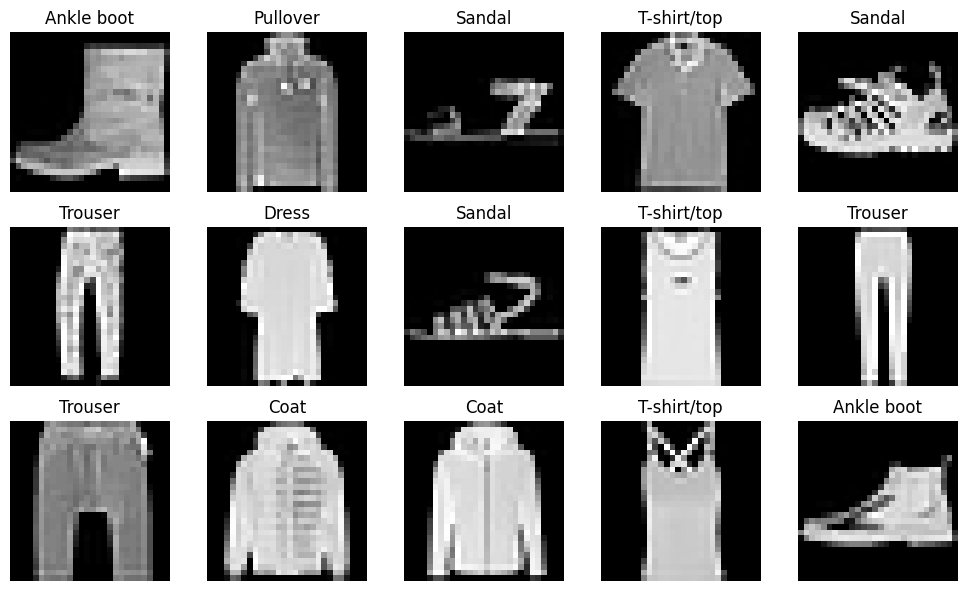

In [11]:
# 可视化 train_dataset 前 15 个样本
fig, axs = plt.subplots(3, 5, figsize=(10, 6))  # 创建 3×5 子图网格
axs = axs.flatten()  # 将二维子图数组展平为一维，便于遍历
for i in range(15):  # 遍历前 15 个样本
    img, label = train_dataset[i]  # 获取第 i 个样本的图像张量和标签
    img = img.squeeze().numpy()  # 去掉通道维度，变成 2D numpy 数组 (28, 28)
    axs[i].imshow(img, cmap='gray')  # 以灰度图显示
    axs[i].set_title(class_names[label])  # 标题设为类别名称
    axs[i].axis('off')  # 关闭坐标轴
plt.tight_layout()  # 自动调整子图间距
plt.show()  # 显示图像

In [12]:
# 查看单条样本的 shape 和标签
print("单条样本 shape:", train_dataset[0][0].shape)  # torch.Size([1, 28, 28])：单通道 28×28 灰度图
print("单条样本标签:", train_dataset[0][1])  # 9

单条样本 shape: torch.Size([1, 28, 28])
单条样本标签: 9


In [13]:
# 判断设备：如果有 GPU 则用 GPU，否则用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")  # 打印当前使用的设备

使用设备: cuda


### 1.2 模型1：简单3层全连接网络（无标准化，无早停，10 epoch）

In [14]:
class Simple3LayerNN(nn.Module):  # 简单3层全连接神经网络，继承 nn.Module
    """三层全连接网络：输入 784 → 300 → 100 → 10"""

    def __init__(self):  # 初始化方法，定义网络各层
        super().__init__()  # 调用父类 nn.Module 的初始化
        self.fc1 = nn.Linear(28 * 28, 300)  # 第1全连接层：784 → 300
        self.relu1 = nn.ReLU()  # ReLU 激活函数，引入非线性
        self.fc2 = nn.Linear(300, 100)  # 第2全连接层：300 → 100
        self.relu2 = nn.ReLU()  # ReLU 激活函数
        self.fc3 = nn.Linear(100, 10)  # 第3全连接层（输出层）：100 → 10 类别 logits

    def forward(self, x):  # 前向传播：定义数据流动顺序
        x = x.view(x.size(0), -1)  # 展平：(batch, 1, 28, 28) → (batch, 784)
        x = self.fc1(x)  # 全连接层1：(batch, 784) → (batch, 300)
        x = self.relu1(x)  # ReLU 激活
        x = self.fc2(x)  # 全连接层2：(batch, 300) → (batch, 100)
        x = self.relu2(x)  # ReLU 激活
        x = self.fc3(x)  # 全连接层3（输出层）：(batch, 100) → (batch, 10)
        return x  # 返回 logits（未过 softmax）


# 实例化模型
model_simple = Simple3LayerNN()  # 创建简单3层网络实例

In [15]:
# 输出模型各层参数及总参数量
print("\n===== 模型1：简单3层网络参数 =====")
for name, param in model_simple.named_parameters():  # 遍历模型所有可学习参数
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")  # 参数名、形状、数量
total_params = sum(p.numel() for p in model_simple.parameters())  # 计算总参数量
print(f"Total number of parameters: {total_params}")  # 266610


===== 模型1：简单3层网络参数 =====
Name: fc1.weight, Shape: torch.Size([300, 784]), Number of params: 235200
Name: fc1.bias, Shape: torch.Size([300]), Number of params: 300
Name: fc2.weight, Shape: torch.Size([100, 300]), Number of params: 30000
Name: fc2.bias, Shape: torch.Size([100]), Number of params: 100
Name: fc3.weight, Shape: torch.Size([10, 100]), Number of params: 1000
Name: fc3.bias, Shape: torch.Size([10]), Number of params: 10
Total number of parameters: 266610


In [16]:
# 设置交叉熵损失函数和 SGD 优化器
criterion_ce = nn.CrossEntropyLoss()  # 交叉熵损失：内部自动做 softmax 再算 NLL loss，默认为样本平均
optimizer_sgd = optim.SGD(model_simple.parameters(), lr=0.01, momentum=0.9)  # SGD + Momentum

In [17]:
model_simple.to(device)  # 模型移至设备

Simple3LayerNN(
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


===== 训练模型1：简单3层网络 =====
Epoch [1/10], Step [100/860], Loss: 0.5660
Epoch [1/10], Step [200/860], Loss: 0.5487
Epoch [1/10], Step [300/860], Loss: 0.4330
Epoch [1/10], Step [400/860], Loss: 0.5732
Epoch [1/10], Step [500/860], Loss: 0.3132
Epoch [1/10], Step [600/860], Loss: 0.4181
Epoch [1/10], Step [700/860], Loss: 0.3235
Epoch [1/10], Step [800/860], Loss: 0.5609
Epoch [1/10], Loss: 0.5365, Train Loss: 0.3871, Val Loss: 0.4115, Train Acc: 85.56%, Val Acc: 84.60%
Epoch [2/10], Step [100/860], Loss: 0.4839
Epoch [2/10], Step [200/860], Loss: 0.3890
Epoch [2/10], Step [300/860], Loss: 0.5259
Epoch [2/10], Step [400/860], Loss: 0.3520
Epoch [2/10], Step [500/860], Loss: 0.4422
Epoch [2/10], Step [600/860], Loss: 0.3325
Epoch [2/10], Step [700/860], Loss: 0.2447
Epoch [2/10], Step [800/860], Loss: 0.3323
Epoch [2/10], Loss: 0.3652, Train Loss: 0.3084, Val Loss: 0.3512, Train Acc: 88.70%, Val Acc: 87.24%
Epoch [3/10], Step [100/860], Loss: 0.3726
Epoch [3/10], Step [200/860], Loss: 0.209

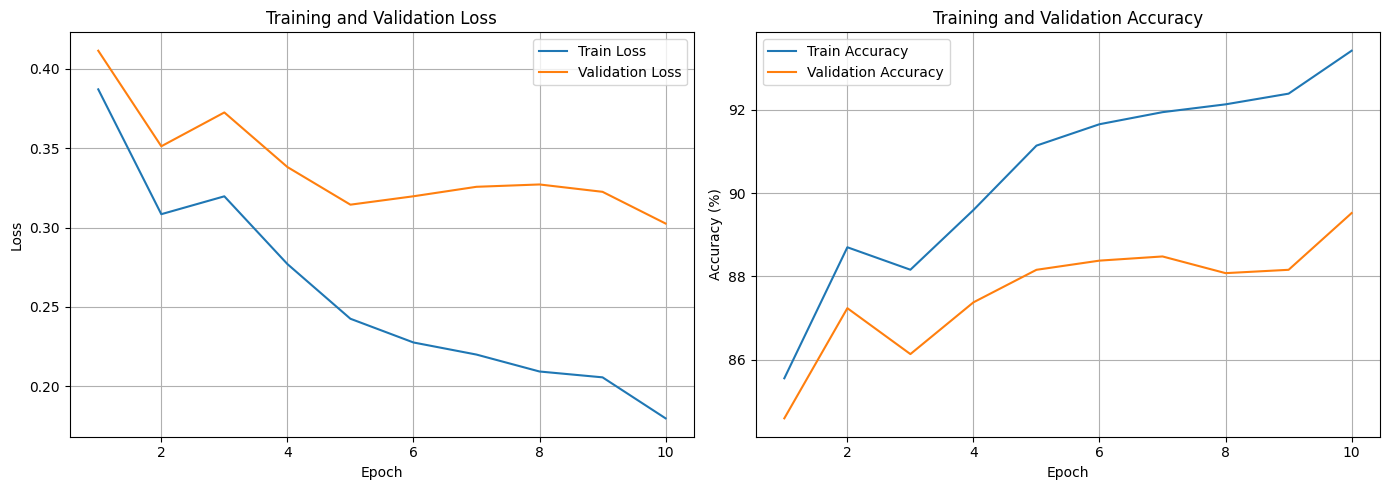

In [18]:
# 创建 Trainer 并训练（简单3层，10 epoch，无早停）
print("\n===== 训练模型1：简单3层网络 =====")
trainer_simple = Trainer(  # 实例化训练器
    model=model_simple,  # 传入模型
    trainloader=train_loader,  # 传入训练集 DataLoader
    valloader=val_loader,  # 传入验证集 DataLoader
    criterion=criterion_ce,  # 传入损失函数
    optimizer=optimizer_sgd,  # 传入优化器
    device=device,  # 传入训练设备
    epochs=10,  # 训练 10 轮
    early_stopping=False,  # 不启用早停
    use_tensorboard=False,  # 暂时关闭 TensorBoard
)
trainer_simple.train()  # 开始分类训练
trainer_simple.plot()  # 绘制损失和准确率曲线

In [19]:
# 在测试集上评估
test_loss, test_acc = trainer_simple.evaluating(test_loader)  # 对测试集做评估
print(f"模型1 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型1 测试集结果 - Test Loss: 0.3256, Test Accuracy: 89.01%


### 1.3 模型2：3层网络 + 标准化 + 早停（acc 判据，30 epoch）

In [20]:
# 重新创建一个 Simple3LayerNN 实例用于模型2
model_more_control = Simple3LayerNN()  # 与模型1结构完全相同
optimizer_more = optim.SGD(model_more_control.parameters(), lr=0.01, momentum=0.9)  # SGD + Momentum
model_more_control.to(device)  # 模型移至设备

Simple3LayerNN(
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


===== 训练模型2：3层网络 + 标准化 + 早停 =====
Epoch [1/30], Step [100/860], Loss: 0.7241
Epoch [1/30], Step [200/860], Loss: 0.4494
Epoch [1/30], Step [300/860], Loss: 0.4686
Epoch [1/30], Step [400/860], Loss: 0.3730
Epoch [1/30], Step [500/860], Loss: 0.4309
Epoch [1/30], Step [600/860], Loss: 0.6363
Epoch [1/30], Step [700/860], Loss: 0.4228
Epoch [1/30], Step [800/860], Loss: 0.3784
Epoch [1/30], Loss: 0.5345, Train Loss: 0.3703, Val Loss: 0.3976, Train Acc: 86.66%, Val Acc: 85.66%
[Info] Model improved at epoch 1, saving to best_model.pth
Epoch [2/30], Step [100/860], Loss: 0.3522
Epoch [2/30], Step [200/860], Loss: 0.2872
Epoch [2/30], Step [300/860], Loss: 0.2715
Epoch [2/30], Step [400/860], Loss: 0.3311
Epoch [2/30], Step [500/860], Loss: 0.2474
Epoch [2/30], Step [600/860], Loss: 0.4238
Epoch [2/30], Step [700/860], Loss: 0.5076
Epoch [2/30], Step [800/860], Loss: 0.5490
Epoch [2/30], Loss: 0.3674, Train Loss: 0.3392, Val Loss: 0.3789, Train Acc: 87.47%, Val Acc: 86.24%
[Info] Model imp

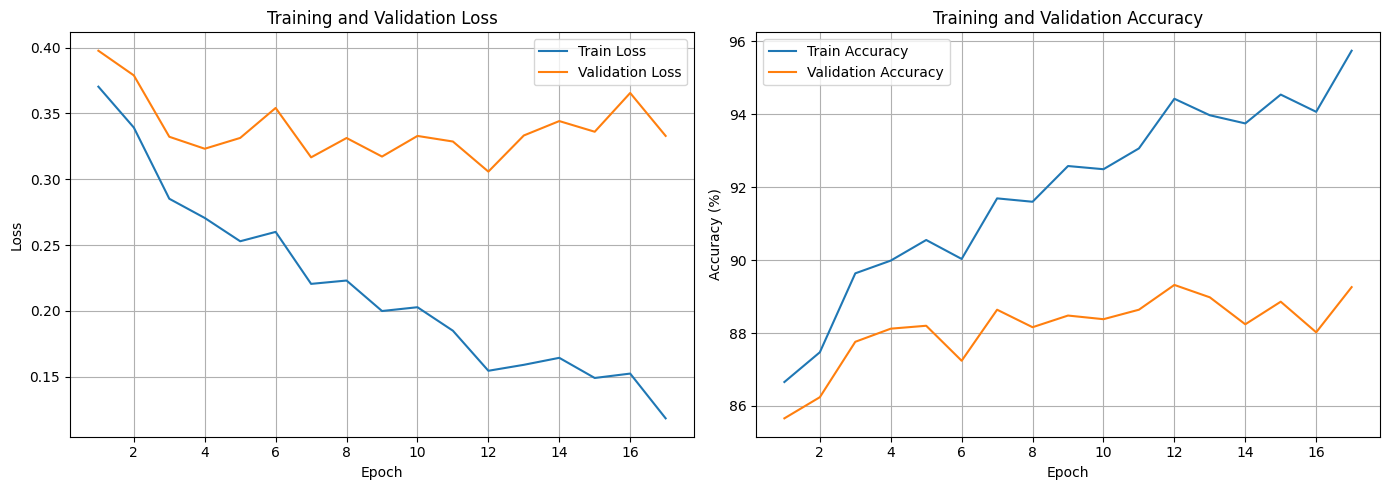

In [21]:
print("\n===== 训练模型2：3层网络 + 标准化 + 早停 =====")
trainer_more_control = Trainer(  # 实例化训练器
    model=model_more_control,  # 传入模型
    trainloader=train_loader,  # 传入训练集 DataLoader（含 Normalize）
    valloader=val_loader,  # 传入验证集 DataLoader
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_more,  # SGD 优化器
    device=device,  # 训练设备
    epochs=30,  # 训练 30 轮
    early_stopping=True,  # 启用早停
    patience=5,  # 连续 5 轮无提升则停止
    early_stop_mode="acc",  # 以验证集准确率作为早停依据
    maximize_acc=True,  # 准确率越大越好
    use_tensorboard=False,  # 暂时关闭 TensorBoard
)
trainer_more_control.train()  # 开始训练
trainer_more_control.plot()  # 绘制损失和准确率曲线

In [22]:
test_loss, test_acc = trainer_more_control.evaluating(test_loader)  # 在测试集评估
print(f"模型2 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型2 测试集结果 - Test Loss: 0.3211, Test Accuracy: 89.20%


### 1.4 模型3 & 4：深度神经网络 DNN（20层，ReLU / 无早停 vs 早停）

In [23]:
class DeepNN_ReLU(nn.Module):  # 深度全连接网络（ReLU），继承 nn.Module
    """20层深度全连接网络：784→100 → 18×[100→100+ReLU] → 10"""

    def __init__(self):  # 初始化
        super().__init__()  # 调用父类初始化
        layers = []  # 用列表收集各层
        input_size = 28 * 28  # 输入维度 = 784
        output_size = 10  # 输出维度 = 10（10分类）
        # 第一层：输入 → 100
        layers.append(nn.Linear(input_size, 100))  # 第1层全连接：784 → 100
        layers.append(nn.ReLU())  # ReLU 激活
        # 添加 18 个隐藏层：100 → 100（每个都带 ReLU）
        for _ in range(18):  # 循环 18 次
            layers.append(nn.Linear(100, 100))  # 全连接层：100 → 100
            layers.append(nn.ReLU())  # ReLU 激活
        # 最终输出层：100 → 10
        layers.append(nn.Linear(100, output_size))  # 输出层：100 → 10
        self.net = nn.Sequential(*layers)  # 用 Sequential 组装所有层

        # Xavier 均匀初始化：使每层输出的方差尽量一致，缓解梯度消失/爆炸
        for m in self.net:  # 遍历网络中每一层
            if isinstance(m, nn.Linear):  # 如果是全连接层
                init.xavier_uniform_(m.weight)  # 对权重做 Xavier 均匀初始化
                if m.bias is not None:  # 如果该层有偏置
                    nn.init.zeros_(m.bias)  # 偏置初始化为 0

    def forward(self, x):  # 前向传播
        x = x.view(x.size(0), -1)  # 展平成 (batch_size, 784)
        x = self.net(x)  # 依次通过所有层
        return x  # 返回 logits

DeepNN_ReLU(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): ReLU()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): ReLU()
    (12): Linear(in_features=100, out_features=100, bias=True)
    (13): ReLU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): ReLU()
    (16): Linear(in_features=100, out_features=100, bias=True)
    (17): ReLU()
    (18): Linear(in_features=100, out_features=100, bias=True)
    (19): ReLU()
    (20): Linear(in_features=100, out_features=100, bias=True)
    (21): ReLU()
    (22): Linear(in_features=100, out_features=100, bias=True)
    (23): ReLU()
    (24): Linear

In [ ]:
# ===== 模型3：DNN + ReLU，无早停，50 epoch =====
model_dnn_noes = DeepNN_ReLU()  # 实例化深度网络
optimizer_dnn_noes = optim.SGD(model_dnn_noes.parameters(), lr=0.01, momentum=0.9)  # SGD 优化器
model_dnn_noes.to(device)  # 移至设备


===== 训练模型3：DNN(ReLU) 无早停 50 epoch =====
Epoch [1/50], Step [100/860], Loss: 2.2798
Epoch [1/50], Step [200/860], Loss: 1.3223
Epoch [1/50], Step [300/860], Loss: 1.0273
Epoch [1/50], Step [400/860], Loss: 0.6530
Epoch [1/50], Step [500/860], Loss: 0.7203
Epoch [1/50], Step [600/860], Loss: 0.5770
Epoch [1/50], Step [700/860], Loss: 0.7052
Epoch [1/50], Step [800/860], Loss: 0.5841
Epoch [1/50], Loss: 1.0761, Train Loss: 0.6572, Val Loss: 0.6884, Train Acc: 75.04%, Val Acc: 74.38%
Epoch [2/50], Step [100/860], Loss: 0.6842
Epoch [2/50], Step [200/860], Loss: 0.3879
Epoch [2/50], Step [300/860], Loss: 0.6483
Epoch [2/50], Step [400/860], Loss: 0.3369
Epoch [2/50], Step [500/860], Loss: 0.5953
Epoch [2/50], Step [600/860], Loss: 0.5258
Epoch [2/50], Step [700/860], Loss: 0.5946
Epoch [2/50], Step [800/860], Loss: 0.5006
Epoch [2/50], Loss: 0.5414, Train Loss: 0.5269, Val Loss: 0.5722, Train Acc: 82.05%, Val Acc: 80.64%
Epoch [3/50], Step [100/860], Loss: 0.4803
Epoch [3/50], Step [200/8

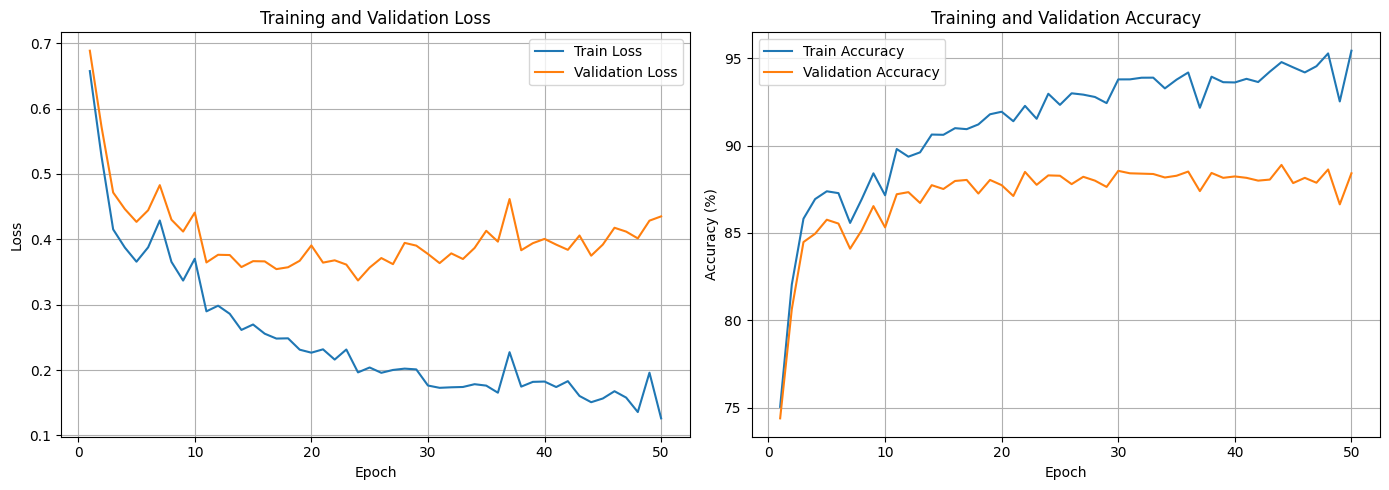

In [24]:
print("\n===== 训练模型3：DNN(ReLU) 无早停 50 epoch =====")
trainer_dnn_noes = Trainer(  # 实例化训练器
    model=model_dnn_noes,  # 传入深度网络
    trainloader=train_loader,  # 训练集加载器
    valloader=val_loader,  # 验证集加载器
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_dnn_noes,  # SGD 优化器
    device=device,  # 训练设备
    epochs=50,  # 训练 50 轮
    early_stopping=False,  # 不启用早停
    use_tensorboard=False,  # 关闭 TensorBoard
    save_path="best_model_dnn.pth",  # 模型保存路径（加 dnn 后缀）
)
trainer_dnn_noes.train()  # 开始训练
trainer_dnn_noes.plot()  # 绘制训练曲线

In [25]:
test_loss, test_acc = trainer_dnn_noes.evaluating(test_loader)  # 测试集评估
print(f"模型3 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型3 测试集结果 - Test Loss: 0.4286, Test Accuracy: 88.40%


In [26]:
# ===== 模型4：DNN + ReLU，启用早停，30 epoch =====
model_dnn_es = DeepNN_ReLU()  # 重新实例化深度网络
optimizer_dnn_es = optim.SGD(model_dnn_es.parameters(), lr=0.01, momentum=0.9)  # SGD 优化器
model_dnn_es.to(device)  # 移至设备

DeepNN_ReLU(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): ReLU()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): ReLU()
    (12): Linear(in_features=100, out_features=100, bias=True)
    (13): ReLU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): ReLU()
    (16): Linear(in_features=100, out_features=100, bias=True)
    (17): ReLU()
    (18): Linear(in_features=100, out_features=100, bias=True)
    (19): ReLU()
    (20): Linear(in_features=100, out_features=100, bias=True)
    (21): ReLU()
    (22): Linear(in_features=100, out_features=100, bias=True)
    (23): ReLU()
    (24): Linear


===== 训练模型4：DNN(ReLU) + 早停 30 epoch =====
Epoch [1/30], Step [100/860], Loss: 2.3038
Epoch [1/30], Step [200/860], Loss: 2.2567
Epoch [1/30], Step [300/860], Loss: 1.3471
Epoch [1/30], Step [400/860], Loss: 1.1919
Epoch [1/30], Step [500/860], Loss: 0.9344
Epoch [1/30], Step [600/860], Loss: 0.8960
Epoch [1/30], Step [700/860], Loss: 0.9651
Epoch [1/30], Step [800/860], Loss: 0.6374
Epoch [1/30], Loss: 1.3405, Train Loss: 0.6515, Val Loss: 0.6683, Train Acc: 78.31%, Val Acc: 77.78%
[Info] Model improved at epoch 1, saving to best_model_dnn.pth
Epoch [2/30], Step [100/860], Loss: 0.5640
Epoch [2/30], Step [200/860], Loss: 0.2978
Epoch [2/30], Step [300/860], Loss: 0.8959
Epoch [2/30], Step [400/860], Loss: 0.5882
Epoch [2/30], Step [500/860], Loss: 0.7917
Epoch [2/30], Step [600/860], Loss: 0.5462
Epoch [2/30], Step [700/860], Loss: 0.7785
Epoch [2/30], Step [800/860], Loss: 0.5702
Epoch [2/30], Loss: 0.6778, Train Loss: 0.5999, Val Loss: 0.6418, Train Acc: 78.37%, Val Acc: 77.30%
[Inf

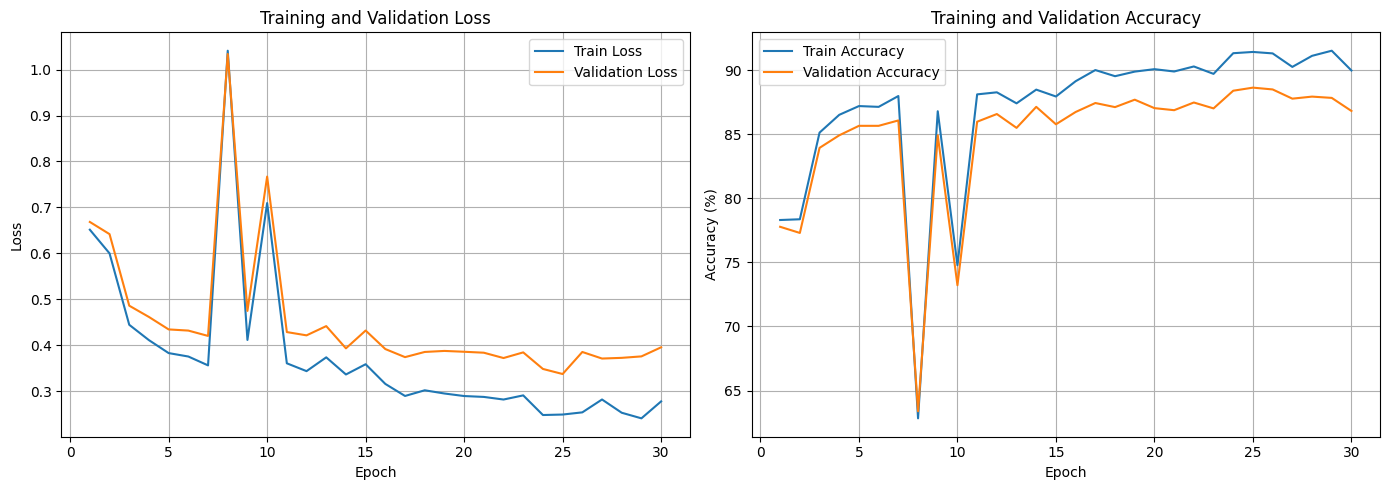

In [27]:
print("\n===== 训练模型4：DNN(ReLU) + 早停 30 epoch =====")
trainer_dnn_es = Trainer(  # 实例化训练器
    model=model_dnn_es,  # 深度网络
    trainloader=train_loader,  # 训练集加载器
    valloader=val_loader,  # 验证集加载器
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_dnn_es,  # SGD 优化器
    device=device,  # 训练设备
    epochs=30,  # 训练 30 轮
    early_stopping=True,  # 开启早停
    patience=5,  # 容忍 5 轮
    early_stop_mode="acc",  # 以准确率为早停依据
    maximize_acc=True,  # 准确率越大越好
    save_path="best_model_dnn.pth",  # 保存最优权重
    use_tensorboard=False,  # 关闭 TensorBoard
)
trainer_dnn_es.train()  # 开始训练
trainer_dnn_es.plot()  # 绘制训练曲线

In [28]:
test_loss, test_acc = trainer_dnn_es.evaluating(test_loader)  # 测试集评估
print(f"模型4 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型4 测试集结果 - Test Loss: 0.3621, Test Accuracy: 88.41%


### 1.5 模型5：DNN + BatchNorm（批归一化）
   BatchNorm 对每个 mini-batch 做归一化，使各层输入分布稳定，
   可加速收敛、允许更大学习率、减少对初始化的敏感性。

In [29]:
class DeepNN_BatchNorm(nn.Module):  # 带 BatchNorm 的深度网络
    """20层 DNN + BatchNorm1d：784→100 → 18×[100→100+BN+ReLU] → 10"""

    def __init__(self):  # 初始化
        super().__init__()  # 调用父类初始化
        layers = []  # 层列表
        input_size = 28 * 28  # 输入维度
        output_size = 10  # 输出维度（10分类）
        # 第一层
        layers.append(nn.Linear(input_size, 100))  # 全连接：784 → 100
        layers.append(nn.ReLU())  # ReLU 激活
        # 18 个隐藏层，每层加 BatchNorm + ReLU
        for _ in range(18):  # 循环 18 次
            layers.append(nn.Linear(100, 100))  # 全连接：100 → 100
            layers.append(nn.BatchNorm1d(100))  # 批归一化：对每个特征维度做归一化
            layers.append(nn.ReLU())  # ReLU 激活
        # 输出层（不加 BN/ReLU）
        layers.append(nn.Linear(100, output_size))  # 输出层：100 → 10
        self.net = nn.Sequential(*layers)  # 用 Sequential 组装

        # Xavier 均匀初始化
        for m in self.net:  # 遍历每一层
            if isinstance(m, nn.Linear):  # 是全连接层
                init.xavier_uniform_(m.weight)  # Xavier 初始化权重
                if m.bias is not None:  # 有偏置
                    nn.init.zeros_(m.bias)  # 偏置置零

    def forward(self, x):  # 前向传播
        x = x.view(x.size(0), -1)  # 展平
        x = self.net(x)  # 通过所有层
        return x  # 返回 logits


model_bn = DeepNN_BatchNorm()  # 实例化 BN 网络
optimizer_bn = optim.SGD(model_bn.parameters(), lr=0.01, momentum=0.9)  # SGD 优化器

In [30]:
# 输出各层参数 shape（观察 BN 层引入的可学习参数 gamma 和 beta）
print("\n===== 模型5：DNN + BatchNorm 参数 shape =====")
for name, param in model_bn.named_parameters():  # 遍历参数
    print(f"{name}: {param.shape}")  # 打印参数名和形状

model_bn.to(device)  # 移至设备


===== 模型5：DNN + BatchNorm 参数 shape =====
net.0.weight: torch.Size([100, 784])
net.0.bias: torch.Size([100])
net.2.weight: torch.Size([100, 100])
net.2.bias: torch.Size([100])
net.3.weight: torch.Size([100])
net.3.bias: torch.Size([100])
net.5.weight: torch.Size([100, 100])
net.5.bias: torch.Size([100])
net.6.weight: torch.Size([100])
net.6.bias: torch.Size([100])
net.8.weight: torch.Size([100, 100])
net.8.bias: torch.Size([100])
net.9.weight: torch.Size([100])
net.9.bias: torch.Size([100])
net.11.weight: torch.Size([100, 100])
net.11.bias: torch.Size([100])
net.12.weight: torch.Size([100])
net.12.bias: torch.Size([100])
net.14.weight: torch.Size([100, 100])
net.14.bias: torch.Size([100])
net.15.weight: torch.Size([100])
net.15.bias: torch.Size([100])
net.17.weight: torch.Size([100, 100])
net.17.bias: torch.Size([100])
net.18.weight: torch.Size([100])
net.18.bias: torch.Size([100])
net.20.weight: torch.Size([100, 100])
net.20.bias: torch.Size([100])
net.21.weight: torch.Size([100])
net

DeepNN_BatchNorm(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (16): ReLU()
    (17): Linear(in_features=100, ou


===== 训练模型5：DNN + BatchNorm =====
Epoch [1/30], Step [100/860], Loss: 1.0773
Epoch [1/30], Step [200/860], Loss: 1.0066
Epoch [1/30], Step [300/860], Loss: 0.9821
Epoch [1/30], Step [400/860], Loss: 0.8592
Epoch [1/30], Step [500/860], Loss: 0.8112
Epoch [1/30], Step [600/860], Loss: 0.7374
Epoch [1/30], Step [700/860], Loss: 0.7646
Epoch [1/30], Step [800/860], Loss: 0.6093
Epoch [1/30], Loss: 0.9033, Train Loss: 0.6797, Val Loss: 0.7109, Train Acc: 75.46%, Val Acc: 74.26%
[Info] Model improved at epoch 1, saving to best_model_dnn_bn.pth
Epoch [2/30], Step [100/860], Loss: 0.6538
Epoch [2/30], Step [200/860], Loss: 0.6855
Epoch [2/30], Step [300/860], Loss: 0.5428
Epoch [2/30], Step [400/860], Loss: 0.6391
Epoch [2/30], Step [500/860], Loss: 0.7617
Epoch [2/30], Step [600/860], Loss: 0.7603
Epoch [2/30], Step [700/860], Loss: 0.6411
Epoch [2/30], Step [800/860], Loss: 0.4861
Epoch [2/30], Loss: 0.6084, Train Loss: 0.5224, Val Loss: 0.5578, Train Acc: 80.61%, Val Acc: 79.34%
[Info] Mo

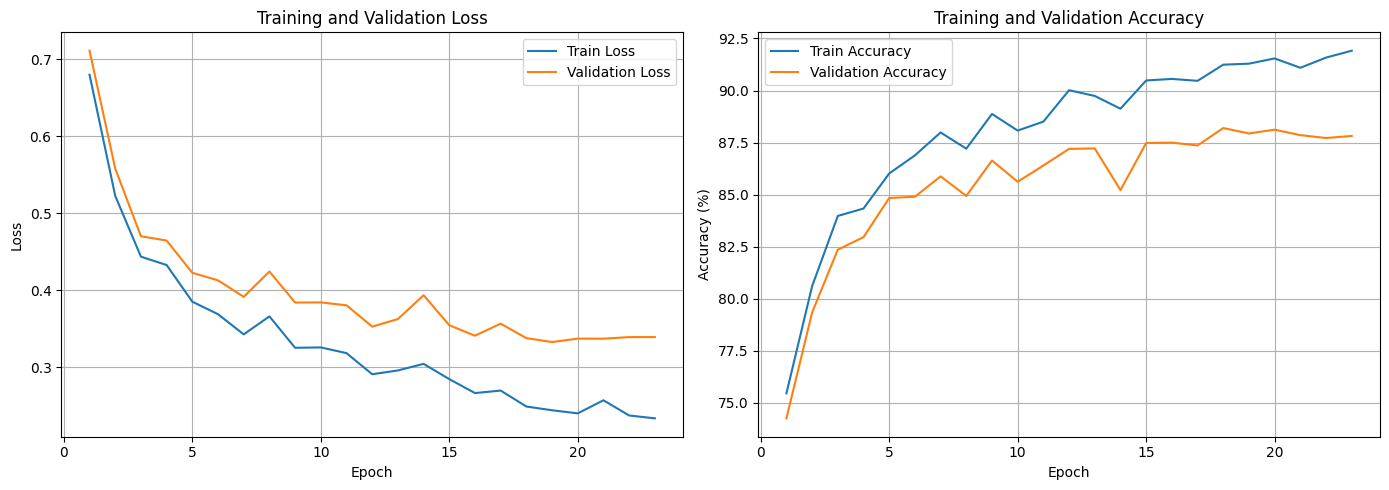

In [31]:
print("\n===== 训练模型5：DNN + BatchNorm =====")
trainer_bn = Trainer(  # 实例化训练器
    model=model_bn,  # BN 网络
    trainloader=train_loader,  # 训练集
    valloader=val_loader,  # 验证集
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_bn,  # SGD 优化器
    device=device,  # 训练设备
    epochs=30,  # 30 轮
    early_stopping=True,  # 启用早停
    patience=5,  # 容忍 5 轮
    early_stop_mode="acc",  # 以准确率为依据
    maximize_acc=True,  # 准确率越大越好
    save_path="best_model_dnn_bn.pth",  # 保存路径
    use_tensorboard=False,  # 关闭 TensorBoard
)
trainer_bn.train()  # 开始训练
trainer_bn.plot()  # 绘制曲线

In [32]:
test_loss, test_acc = trainer_bn.evaluating(test_loader)  # 测试集评估
print(f"模型5 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型5 测试集结果 - Test Loss: 0.3414, Test Accuracy: 87.81%


### 1.6 模型6：DNN + SELU（自归一化激活函数）
   SELU 自带自归一化特性，配合 Xavier 初始化可实现
   各层输出自动趋向均值 0、方差 1，无需 BatchNorm。

In [33]:
class DeepNN_SELU(nn.Module):  # 使用 SELU 激活的深度网络
    """20层 DNN + SELU：784→100 → 18×[100→100+SELU] → 10"""

    def __init__(self):  # 初始化
        super().__init__()  # 父类初始化
        layers = []  # 层列表
        input_size = 28 * 28  # 输入维度
        output_size = 10  # 输出维度
        # 第一层
        layers.append(nn.Linear(input_size, 100))  # 全连接：784 → 100
        layers.append(nn.SELU())  # SELU 激活：自带自归一化特性
        # 18 个隐藏层
        for _ in range(18):  # 循环 18 次
            layers.append(nn.Linear(100, 100))  # 全连接：100 → 100
            layers.append(nn.SELU())  # SELU 激活
        # 输出层
        layers.append(nn.Linear(100, output_size))  # 输出层：100 → 10
        self.net = nn.Sequential(*layers)  # Sequential 组装

        # Xavier 均匀初始化（SELU 论文推荐使用 LeCun 初始化，此处为对比一致性沿用 Xavier）
        for m in self.net:  # 遍历层
            if isinstance(m, nn.Linear):  # 全连接层
                init.xavier_uniform_(m.weight)  # Xavier 初始化权重
                if m.bias is not None:  # 有偏置
                    nn.init.zeros_(m.bias)  # 偏置置零

    def forward(self, x):  # 前向传播
        x = x.view(x.size(0), -1)  # 展平
        x = self.net(x)  # 通过所有层
        return x  # 返回 logits


model_selu = DeepNN_SELU()  # 实例化 SELU 网络
optimizer_selu = optim.SGD(model_selu.parameters(), lr=0.01, momentum=0.9)  # SGD 优化器
model_selu.to(device)  # 移至设备

DeepNN_SELU(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): SELU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): SELU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): SELU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): SELU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): SELU()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): SELU()
    (12): Linear(in_features=100, out_features=100, bias=True)
    (13): SELU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): SELU()
    (16): Linear(in_features=100, out_features=100, bias=True)
    (17): SELU()
    (18): Linear(in_features=100, out_features=100, bias=True)
    (19): SELU()
    (20): Linear(in_features=100, out_features=100, bias=True)
    (21): SELU()
    (22): Linear(in_features=100, out_features=100, bias=True)
    (23): SELU()
    (24): Linear


===== 训练模型6：DNN + SELU =====
Epoch [1/30], Step [100/860], Loss: 0.7040
Epoch [1/30], Step [200/860], Loss: 0.8664
Epoch [1/30], Step [300/860], Loss: 0.6418
Epoch [1/30], Step [400/860], Loss: 0.6068
Epoch [1/30], Step [500/860], Loss: 0.6251
Epoch [1/30], Step [600/860], Loss: 0.5039
Epoch [1/30], Step [700/860], Loss: 0.5106
Epoch [1/30], Step [800/860], Loss: 0.3280
Epoch [1/30], Loss: 0.6331, Train Loss: 0.4768, Val Loss: 0.4979, Train Acc: 83.70%, Val Acc: 83.56%
[Info] Model improved at epoch 1, saving to best_model_dnn_selu.pth
Epoch [2/30], Step [100/860], Loss: 0.5556
Epoch [2/30], Step [200/860], Loss: 0.3494
Epoch [2/30], Step [300/860], Loss: 0.5944
Epoch [2/30], Step [400/860], Loss: 0.3833
Epoch [2/30], Step [500/860], Loss: 0.5280
Epoch [2/30], Step [600/860], Loss: 0.3772
Epoch [2/30], Step [700/860], Loss: 0.6431
Epoch [2/30], Step [800/860], Loss: 0.4831
Epoch [2/30], Loss: 0.4509, Train Loss: 0.3961, Val Loss: 0.4425, Train Acc: 85.25%, Val Acc: 83.40%
[Info] Early

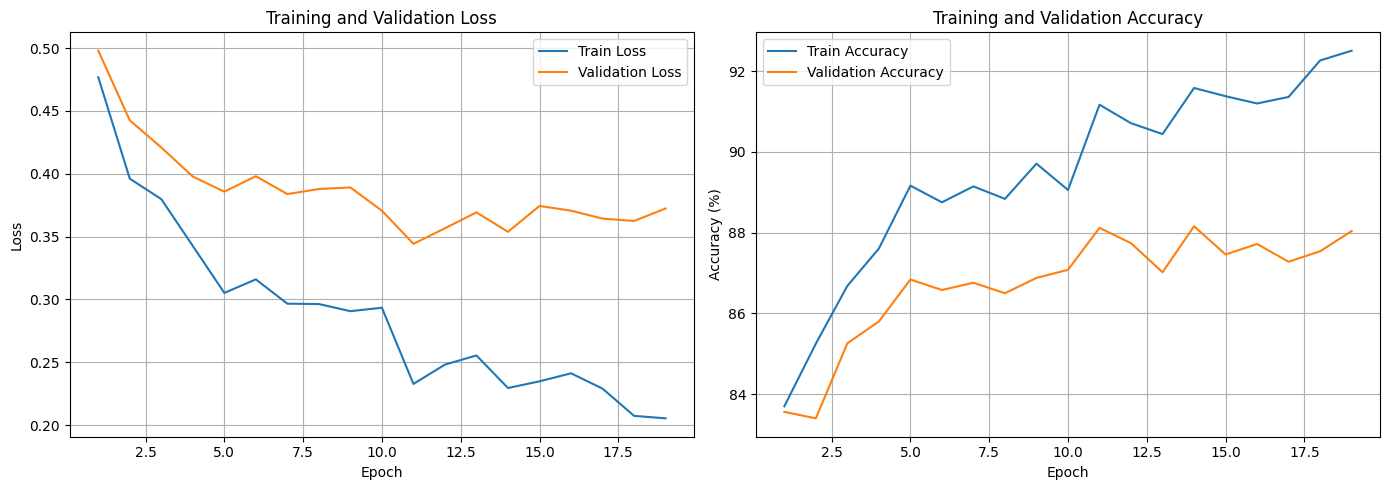

In [34]:
print("\n===== 训练模型6：DNN + SELU =====")
trainer_selu = Trainer(  # 实例化训练器
    model=model_selu,  # SELU 网络
    trainloader=train_loader,  # 训练集
    valloader=val_loader,  # 验证集
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_selu,  # SGD 优化器
    device=device,  # 训练设备
    epochs=30,  # 30 轮
    early_stopping=True,  # 启用早停
    patience=5,  # 容忍 5 轮
    early_stop_mode="acc",  # 以准确率为依据
    maximize_acc=True,  # 准确率越大越好
    save_path="best_model_dnn_selu.pth",  # 保存路径
    use_tensorboard=False,  # 关闭 TensorBoard
)
trainer_selu.train()  # 开始训练
trainer_selu.plot()  # 绘制曲线

In [35]:
test_loss, test_acc = trainer_selu.evaluating(test_loader)  # 测试集评估
print(f"模型6 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型6 测试集结果 - Test Loss: 0.3625, Test Accuracy: 87.89%


### 1.7 模型7：DNN + AlphaDropout（与 SELU 配套的 Dropout）
   AlphaDropout 是专门为 SELU 设计的 Dropout 变体，
   在训练时随机将神经元置为 SELU 的负饱和值（而非 0），
   以保持自归一化特性。

In [36]:
class DeepNN_AlphaDropout(nn.Module):  # 带 AlphaDropout 的深度网络（ReLU + AlphaDropout）
    """20层 DNN + ReLU + AlphaDropout：784→100 → [100→100+ReLU]×18 → 10"""

    def __init__(self):  # 初始化
        super().__init__()  # 父类初始化
        layers = []  # 层列表
        input_size = 28 * 28  # 输入维度
        output_size = 10  # 输出维度
        # 第一层 + ReLU + AlphaDropout
        layers.append(nn.Linear(input_size, 100))  # 全连接：784 → 100
        layers.append(nn.ReLU())  # ReLU 激活
        layers.append(nn.AlphaDropout(p=0.2))  # AlphaDropout：以 0.2 概率随机丢弃（置为负饱和值）
        # 18 个隐藏层
        for _ in range(18):  # 循环 18 次
            layers.append(nn.Linear(100, 100))  # 全连接：100 → 100
            layers.append(nn.ReLU())  # ReLU 激活
        # 输出层
        layers.append(nn.Linear(100, output_size))  # 输出层：100 → 10
        self.net = nn.Sequential(*layers)  # Sequential 组装

        # Xavier 均匀初始化
        for m in self.net:  # 遍历层
            if isinstance(m, nn.Linear):  # 全连接层
                init.xavier_uniform_(m.weight)  # Xavier 初始化权重
                if m.bias is not None:  # 有偏置
                    nn.init.zeros_(m.bias)  # 偏置置零

    def forward(self, x):  # 前向传播
        x = x.view(x.size(0), -1)  # 展平
        x = self.net(x)  # 通过所有层
        return x  # 返回 logits


model_dropout = DeepNN_AlphaDropout()  # 实例化 AlphaDropout 网络
optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.01, momentum=0.9)  # SGD 优化器
model_dropout.to(device)  # 移至设备

DeepNN_AlphaDropout(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): AlphaDropout(p=0.2, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): ReLU()
    (7): Linear(in_features=100, out_features=100, bias=True)
    (8): ReLU()
    (9): Linear(in_features=100, out_features=100, bias=True)
    (10): ReLU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): ReLU()
    (13): Linear(in_features=100, out_features=100, bias=True)
    (14): ReLU()
    (15): Linear(in_features=100, out_features=100, bias=True)
    (16): ReLU()
    (17): Linear(in_features=100, out_features=100, bias=True)
    (18): ReLU()
    (19): Linear(in_features=100, out_features=100, bias=True)
    (20): ReLU()
    (21): Linear(in_features=100, out_features=100, bias=True)
    (22): ReLU()
    (23): Linear(in_features=100, out_featu


===== 训练模型7：DNN + AlphaDropout（无早停 50 epoch）=====
Epoch [1/50], Step [100/860], Loss: 2.2984
Epoch [1/50], Step [200/860], Loss: 2.2880
Epoch [1/50], Step [300/860], Loss: 1.7796
Epoch [1/50], Step [400/860], Loss: 1.5143
Epoch [1/50], Step [500/860], Loss: 1.3068
Epoch [1/50], Step [600/860], Loss: 1.1388
Epoch [1/50], Step [700/860], Loss: 1.0572
Epoch [1/50], Step [800/860], Loss: 1.0858
Epoch [1/50], Loss: 1.5838, Train Loss: 1.0173, Val Loss: 1.0433, Train Acc: 59.13%, Val Acc: 58.36%
Epoch [2/50], Step [100/860], Loss: 0.6633
Epoch [2/50], Step [200/860], Loss: 0.8927
Epoch [2/50], Step [300/860], Loss: 0.7584
Epoch [2/50], Step [400/860], Loss: 0.6688
Epoch [2/50], Step [500/860], Loss: 0.6521
Epoch [2/50], Step [600/860], Loss: 0.7534
Epoch [2/50], Step [700/860], Loss: 0.7062
Epoch [2/50], Step [800/860], Loss: 0.5808
Epoch [2/50], Loss: 0.7621, Train Loss: 0.6195, Val Loss: 0.6484, Train Acc: 75.96%, Val Acc: 75.42%
Epoch [3/50], Step [100/860], Loss: 0.8668
Epoch [3/50], St

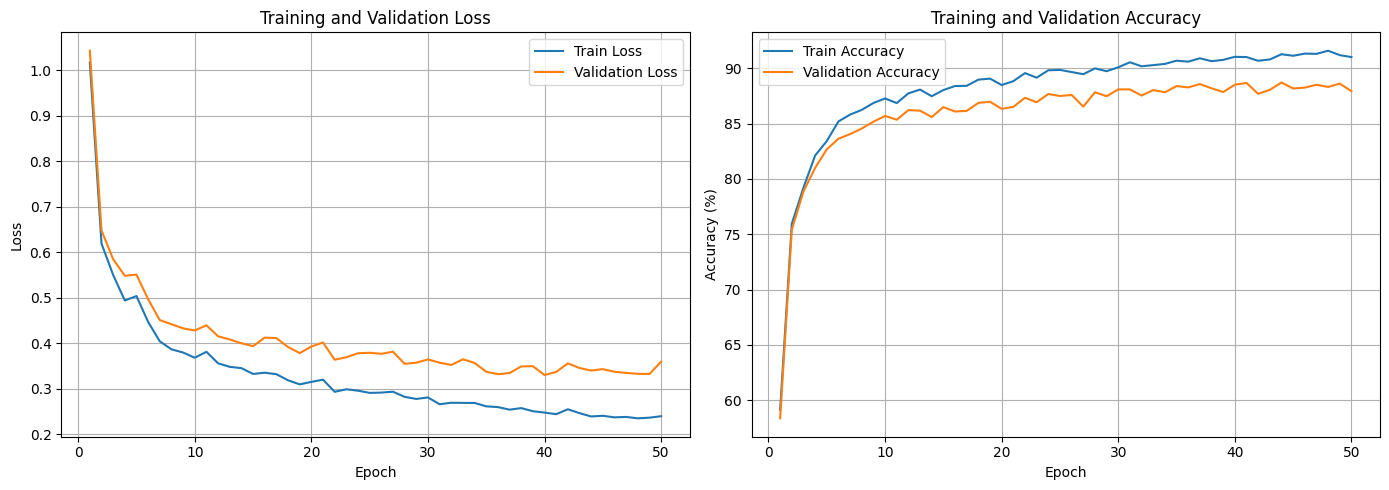

In [37]:
print("\n===== 训练模型7：DNN + AlphaDropout（无早停 50 epoch）=====")
trainer_dropout = Trainer(  # 实例化训练器
    model=model_dropout,  # AlphaDropout 网络
    trainloader=train_loader,  # 训练集
    valloader=val_loader,  # 验证集
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_dropout,  # SGD 优化器
    device=device,  # 训练设备
    epochs=50,  # 训练 50 轮
    early_stopping=False,  # 不启用早停（观察 Dropout 的长期效果）
    save_path="best_model_dnn.pth",  # 保存路径
    use_tensorboard=False,  # 关闭 TensorBoard
)
trainer_dropout.train()  # 开始训练
trainer_dropout.plot()  # 绘制曲线

In [38]:
test_loss, test_acc = trainer_dropout.evaluating(test_loader)  # 测试集评估
print(f"模型7 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型7 测试集结果 - Test Loss: 0.3591, Test Accuracy: 87.80%


### 1.8 模型8：DNN + SELU + AlphaDropout
   SELU 与 AlphaDropout 是最佳搭配：
   SELU 提供自归一化，AlphaDropout 在丢弃时保持自归一化特性。

In [39]:
class DeepNN_SELU_Dropout(nn.Module):  # SELU + AlphaDropout 深度网络
    """20层 DNN + SELU + AlphaDropout：784→100 → 18×[100→100+SELU] → 10"""

    def __init__(self):  # 初始化
        super().__init__()  # 父类初始化
        layers = []  # 层列表
        input_size = 28 * 28  # 输入维度
        output_size = 10  # 输出维度
        # 第一层 + SELU + AlphaDropout
        layers.append(nn.Linear(input_size, 100))  # 全连接：784 → 100
        layers.append(nn.SELU())  # SELU 激活（自归一化）
        layers.append(nn.AlphaDropout(p=0.2))  # AlphaDropout：以 0.2 概率丢弃
        # 18 个隐藏层（SELU 激活，不加 Dropout）
        for _ in range(18):  # 循环 18 次
            layers.append(nn.Linear(100, 100))  # 全连接：100 → 100
            layers.append(nn.SELU())  # SELU 激活
        # 输出层
        layers.append(nn.Linear(100, output_size))  # 输出层：100 → 10
        self.net = nn.Sequential(*layers)  # Sequential 组装

        # Xavier 均匀初始化
        for m in self.net:  # 遍历层
            if isinstance(m, nn.Linear):  # 全连接层
                init.xavier_uniform_(m.weight)  # Xavier 初始化权重
                if m.bias is not None:  # 有偏置
                    nn.init.zeros_(m.bias)  # 偏置置零

    def forward(self, x):  # 前向传播
        x = x.view(x.size(0), -1)  # 展平
        x = self.net(x)  # 通过所有层
        return x  # 返回 logits


model_selu_drop = DeepNN_SELU_Dropout()  # 实例化 SELU + AlphaDropout 网络
optimizer_selu_drop = optim.SGD(model_selu_drop.parameters(), lr=0.01, momentum=0.9)  # SGD 优化器
model_selu_drop.to(device)  # 移至设备

DeepNN_SELU_Dropout(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): SELU()
    (2): AlphaDropout(p=0.2, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): SELU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): SELU()
    (7): Linear(in_features=100, out_features=100, bias=True)
    (8): SELU()
    (9): Linear(in_features=100, out_features=100, bias=True)
    (10): SELU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): SELU()
    (13): Linear(in_features=100, out_features=100, bias=True)
    (14): SELU()
    (15): Linear(in_features=100, out_features=100, bias=True)
    (16): SELU()
    (17): Linear(in_features=100, out_features=100, bias=True)
    (18): SELU()
    (19): Linear(in_features=100, out_features=100, bias=True)
    (20): SELU()
    (21): Linear(in_features=100, out_features=100, bias=True)
    (22): SELU()
    (23): Linear(in_features=100, out_featu


===== 训练模型8：DNN + SELU + AlphaDropout =====
Epoch [1/30], Step [100/860], Loss: 0.9604
Epoch [1/30], Step [200/860], Loss: 0.8291
Epoch [1/30], Step [300/860], Loss: 0.6445
Epoch [1/30], Step [400/860], Loss: 0.9340
Epoch [1/30], Step [500/860], Loss: 0.9507
Epoch [1/30], Step [600/860], Loss: 0.3673
Epoch [1/30], Step [700/860], Loss: 0.7175
Epoch [1/30], Step [800/860], Loss: 0.6458
Epoch [1/30], Loss: 0.7190, Train Loss: 0.5046, Val Loss: 0.5363, Train Acc: 82.92%, Val Acc: 81.78%
[Info] Model improved at epoch 1, saving to best_model_dnn_selu.pth
Epoch [2/30], Step [100/860], Loss: 0.5576
Epoch [2/30], Step [200/860], Loss: 0.4725
Epoch [2/30], Step [300/860], Loss: 0.3305
Epoch [2/30], Step [400/860], Loss: 0.2602
Epoch [2/30], Step [500/860], Loss: 0.6768
Epoch [2/30], Step [600/860], Loss: 0.2277
Epoch [2/30], Step [700/860], Loss: 0.4109
Epoch [2/30], Step [800/860], Loss: 0.4916
Epoch [2/30], Loss: 0.5017, Train Loss: 0.4539, Val Loss: 0.5051, Train Acc: 84.04%, Val Acc: 83.3

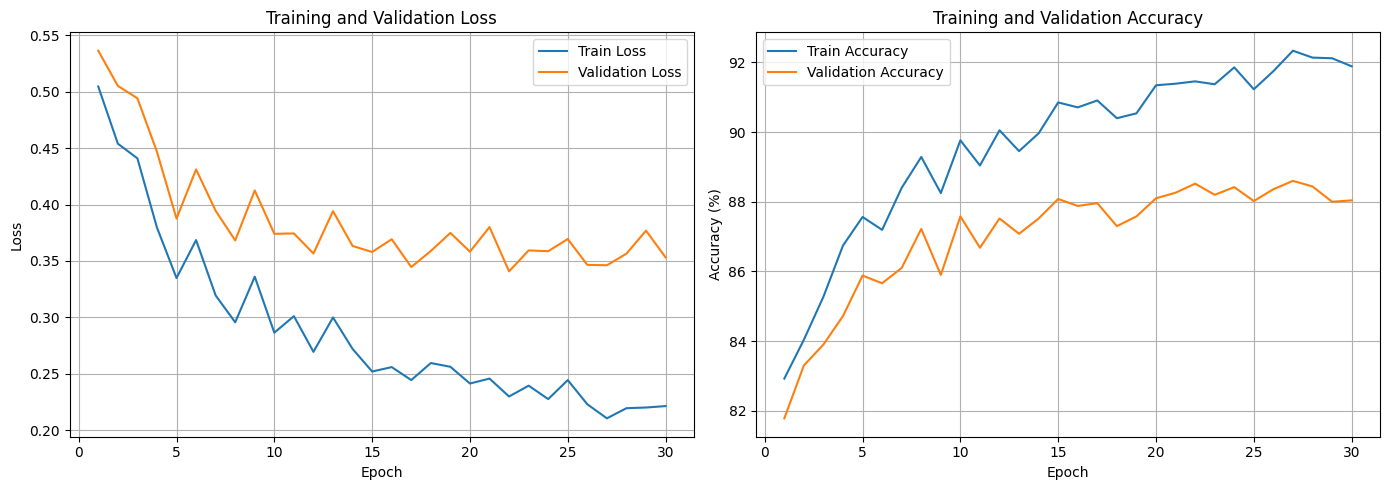

In [40]:
print("\n===== 训练模型8：DNN + SELU + AlphaDropout =====")
trainer_selu_drop = Trainer(  # 实例化训练器
    model=model_selu_drop,  # SELU + AlphaDropout 网络
    trainloader=train_loader,  # 训练集
    valloader=val_loader,  # 验证集
    criterion=criterion_ce,  # 交叉熵损失
    optimizer=optimizer_selu_drop,  # SGD 优化器
    device=device,  # 训练设备
    epochs=30,  # 30 轮
    early_stopping=True,  # 启用早停
    patience=5,  # 容忍 5 轮
    early_stop_mode="acc",  # 以准确率为依据
    maximize_acc=True,  # 准确率越大越好
    save_path="best_model_dnn_selu.pth",  # 保存路径
    use_tensorboard=False,  # 关闭 TensorBoard
)
trainer_selu_drop.train()  # 开始训练
trainer_selu_drop.plot()  # 绘制曲线

In [41]:
test_loss, test_acc = trainer_selu_drop.evaluating(test_loader)  # 测试集评估
print(f"模型8 测试集结果 - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

模型8 测试集结果 - Test Loss: 0.3442, Test Accuracy: 88.87%
